In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

import joblib
import warnings
warnings.filterwarnings("ignore")

model1_logistic = LogisticRegression()
model2_svm = SVC(
    probability=True,
    random_state=42
)
model3_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model4_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [2]:
hd = pd.read_csv("../dataset/heart+disease/processed.cleveland.data")

In [3]:
hd.head()

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [4]:
hd.shape

(302, 14)

In [5]:
hd.columns = [
    "age",
    "sex",
    "chest_pain",
    "resting_bp",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_angina",
    "oldpeak",
    "slope",
    "ca",
    "Thal",
    "target"
]

In [6]:
hd.head()

,age,sex,chest_pain,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,ca,Thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


| Column                | Meaning                           | Simple explanation                                            |
| --------------------- | --------------------------------- | ------------------------------------------------------------- |
| `age`                 | Age                               | Patient ki age, years mein                                    |
| `sex`                 | Sex                               | `1` = male, `0` = female                                      |
| `chest_pain`          | Chest pain type                   | Patient ko kis type ka chest pain hai                         |
| `resting_bp`          | Resting blood pressure            | Rest ki condition mein blood pressure                         |
| `cholesterol`         | Serum cholesterol                 | Blood mein cholesterol level                                  |
| `fasting_blood_sugar` | Fasting blood sugar               | Fasting sugar > 120 mg/dl hai ya nahi                         |
| `resting_ecg`         | Resting ECG result                | Resting condition mein heart ki electrical activity ka result |
| `max_heart_rate`      | Maximum heart rate                | Exercise/test ke during maximum heart rate                    |
| `exercise_angina`     | Exercise-induced angina           | Exercise karne par chest pain hota hai ya nahi                |
| `oldpeak`             | ST depression                     | Exercise ke baad ECG mein ST segment depression               |
| `slope`               | Slope of peak exercise ST segment | Exercise ke peak par ST segment ka slope                      |
| `ca`                  | Number of major vessels           | Fluoroscopy se visible major blood vessels ki count           |
| `thal`                | Thalassemia test/result           | Thalassemia-related blood-flow/test result                    |
| `target`              | Heart disease diagnosis           | Heart disease ki presence/absence ka target                   |


chest_pain:
1 = typical angina
2 = atypical angina
3 = non-anginal pain
4 = asymptomatic

resting_ecg:
0 = normal
1 = ST-T wave abnormality
2 = left ventricular hypertrophy

exercise_angina:
0 = No
1 = Yes

0 = no heart disease
1, 2, 3, 4 = presence/severity of heart disease

In [7]:
hd["target"] = hd["target"].apply(lambda x: 0 if x == 0 else 1)

In [8]:
print(hd["target"].unique())
print(hd["target"].value_counts())

[1 0]
target
0    163
1    139
Name: count, dtype: int64


In [9]:
hd.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  302 non-null    float64
 1   sex                  302 non-null    float64
 2   chest_pain           302 non-null    float64
 3   resting_bp           302 non-null    float64
 4   cholesterol          302 non-null    float64
 5   fasting_blood_sugar  302 non-null    float64
 6   resting_ecg          302 non-null    float64
 7   max_heart_rate       302 non-null    float64
 8   exercise_angina      302 non-null    float64
 9   oldpeak              302 non-null    float64
 10  slope                302 non-null    float64
 11  ca                   302 non-null    str    
 12  Thal                 302 non-null    str    
 13  target               302 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 34.9 KB


In [10]:
hd.shape

(302, 14)

In [11]:
hd.columns

Index(['age', 'sex', 'chest_pain', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'slope', 'ca', 'Thal', 'target'],
      dtype='str')

In [12]:
hd.describe()

,age,sex,chest_pain,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,target
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.410596,0.678808,3.165563,131.645695,246.738411,0.145695,0.986755,149.605960,0.327815,1.035430,1.596026,0.460265
std,9.040163,0.467709,0.953612,17.612202,51.856829,0.353386,0.994916,22.912959,0.470196,1.160723,0.611939,0.499246
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000
50%,55.500000,1.000000,3.000000,130.000000,241.500000,0.000000,0.500000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [13]:
hd.isnull().sum()

age                    0
sex                    0
chest_pain             0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
ca                     0
Thal                   0
target                 0
dtype: int64

In [14]:
unique_data = pd.DataFrame([
    {"Column": column, "Value": value, "Count": count}
    for column in hd.columns
    for value, count in hd[column].value_counts().items()
])

unique_data.head(10)
unique_data.tail(10)

,Column,Value,Count
391,ca,1.0,65
392,ca,2.0,38
393,ca,3.0,20
394,ca,?,4
395,Thal,3.0,166
396,Thal,7.0,117
397,Thal,6.0,17
398,Thal,?,2
399,target,0,163
400,target,1,139


In [15]:
print((hd == "?").sum())

age                    0
sex                    0
chest_pain             0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
ca                     4
Thal                   2
target                 0
dtype: int64


In [16]:
hd = hd.replace("?", np.nan)

In [17]:
hd.isnull().sum()

age                    0
sex                    0
chest_pain             0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
ca                     4
Thal                   2
target                 0
dtype: int64

In [18]:
hd["ca"] = pd.to_numeric(hd["ca"])
hd["Thal"] = pd.to_numeric(hd["Thal"])

In [19]:
hd['Thal'] = hd['Thal'].fillna(hd['Thal'].mode()[0])
hd['ca'] = hd['ca'].fillna(hd['ca'].mode()[0])

In [20]:
hd.isnull().sum()

age                    0
sex                    0
chest_pain             0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
ca                     0
Thal                   0
target                 0
dtype: int64

In [21]:
print("Duplicate rows:", hd.duplicated().sum())

Duplicate rows: 0


In [22]:
hd["target"].value_counts()

target
0    163
1    139
Name: count, dtype: int64

In [23]:
hd["target"].value_counts(normalize =True)*100

target
0    53.97351
1    46.02649
Name: proportion, dtype: float64

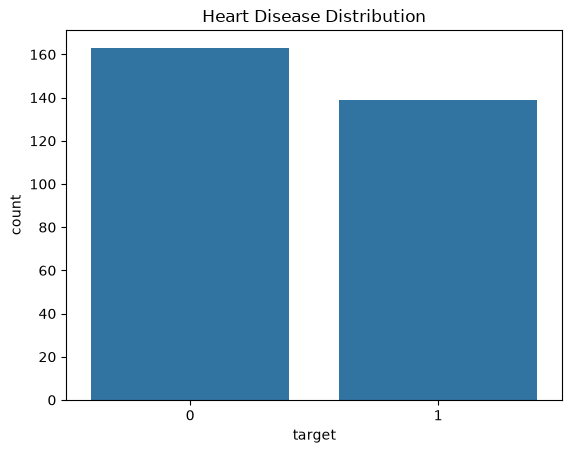

In [24]:
sns.countplot(x="target", data = hd)
plt.title("Heart Disease Distribution")
plt.show()

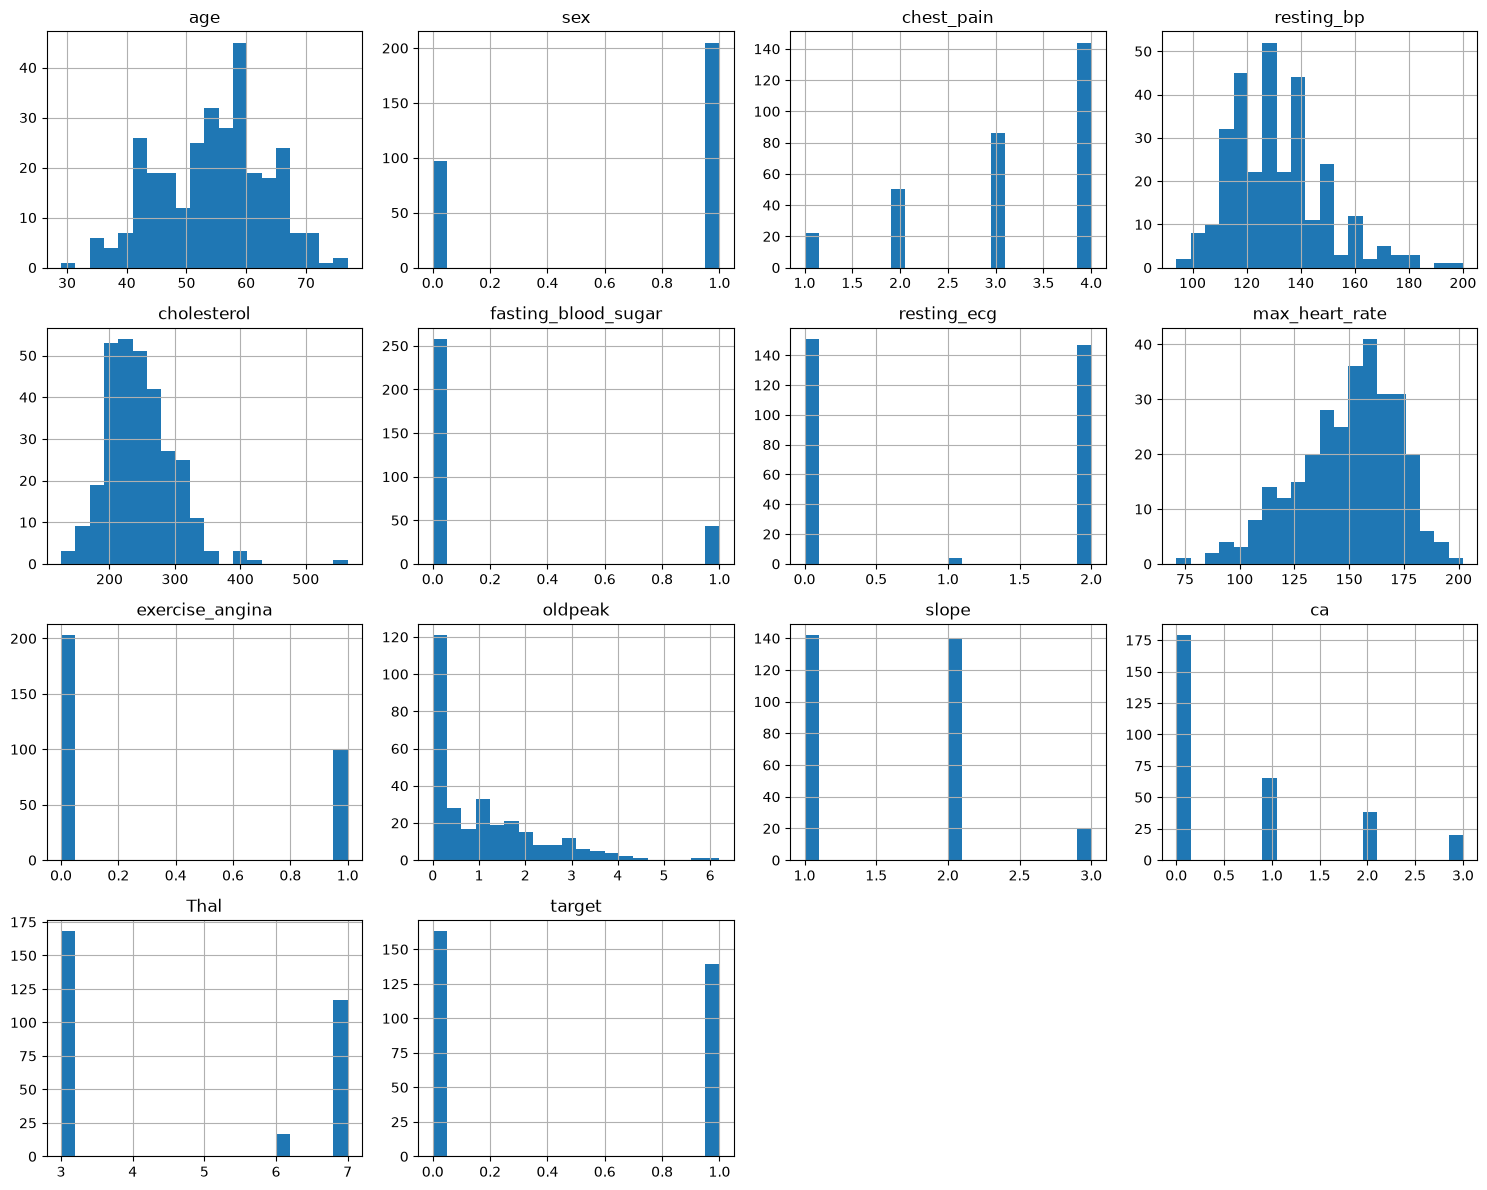

In [25]:
hd.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

In [26]:
categorical_cols = [
    "sex",
    "chest_pain",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_angina",
    "slope",
    "ca",
    "Thal"
]
for col in categorical_cols:
    print(hd[col].value_counts())

sex
1.0    205
0.0     97
Name: count, dtype: int64
chest_pain
4.0    144
3.0     86
2.0     50
1.0     22
Name: count, dtype: int64
fasting_blood_sugar
0.0    258
1.0     44
Name: count, dtype: int64
resting_ecg
0.0    151
2.0    147
1.0      4
Name: count, dtype: int64
exercise_angina
0.0    203
1.0     99
Name: count, dtype: int64
slope
1.0    142
2.0    140
3.0     20
Name: count, dtype: int64
ca
0.0    179
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64
Thal
3.0    168
7.0    117
6.0     17
Name: count, dtype: int64


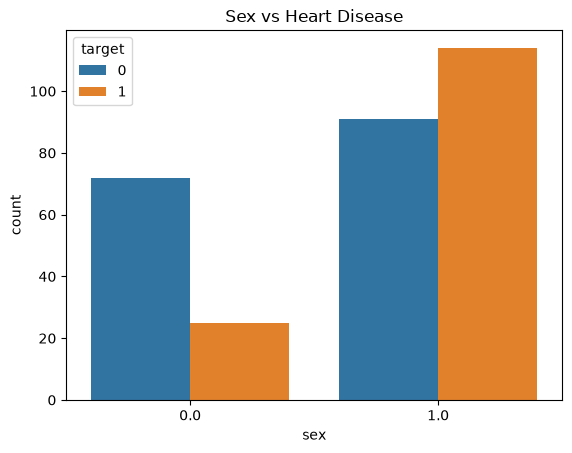

In [27]:
sns.countplot(x="sex", hue="target", data=hd)
plt.title("Sex vs Heart Disease")
plt.show()

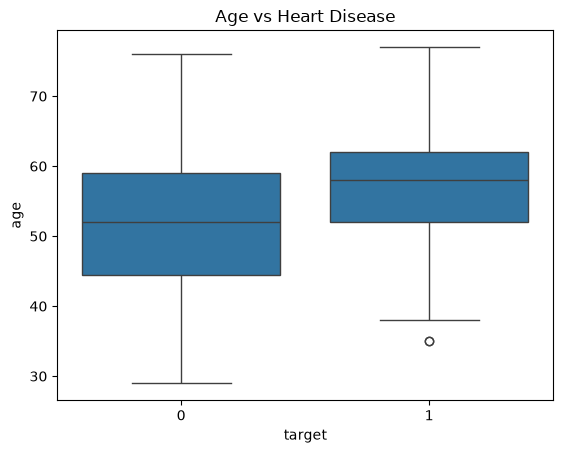

In [28]:
sns.boxplot(x="target", y="age", data=hd)
plt.title("Age vs Heart Disease")
plt.show()

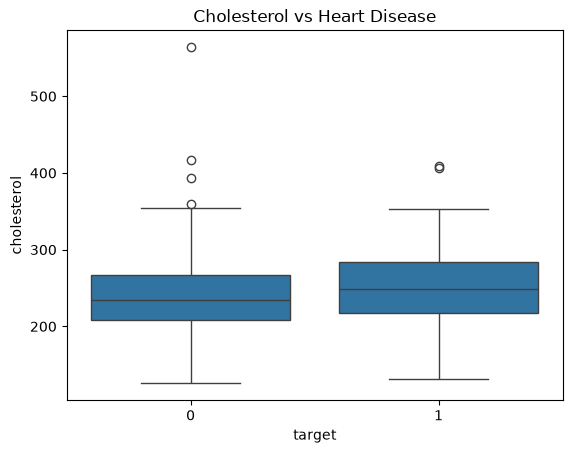

In [29]:
sns.boxplot(x="target", y="cholesterol", data=hd)
plt.title("Cholesterol vs Heart Disease")
plt.show()

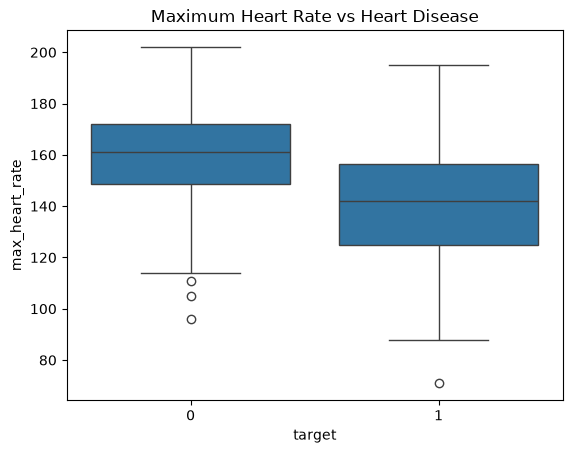

In [30]:
sns.boxplot(x="target", y="max_heart_rate", data=hd)
plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()

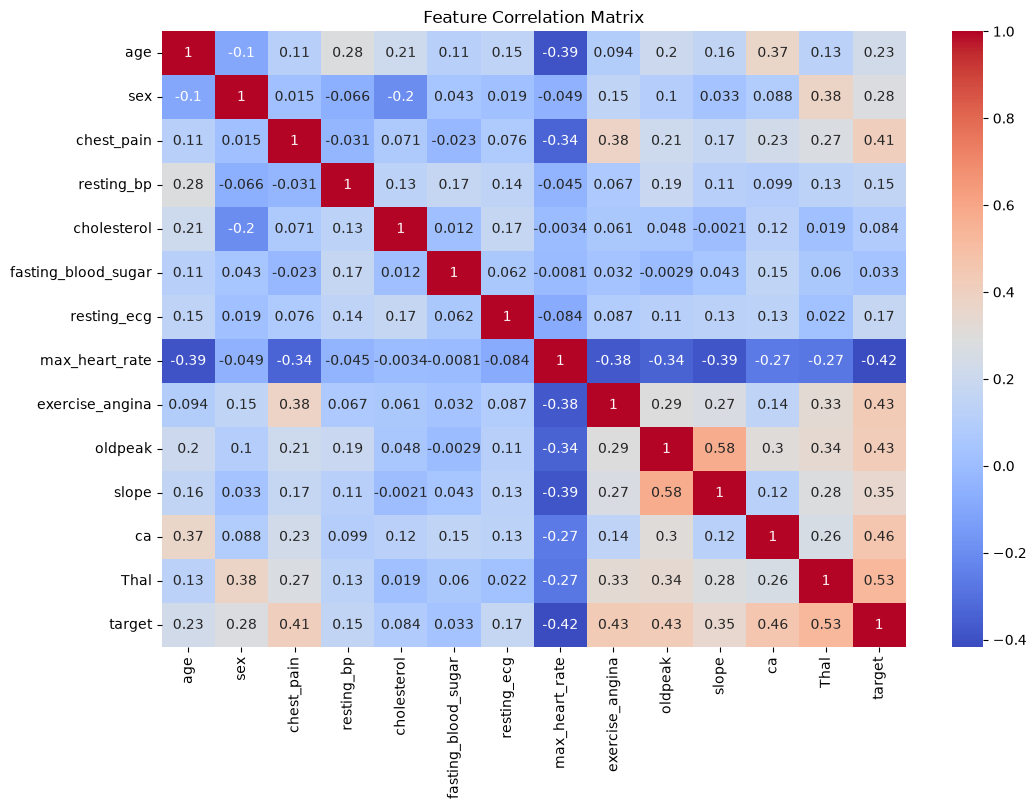

In [31]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    hd.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

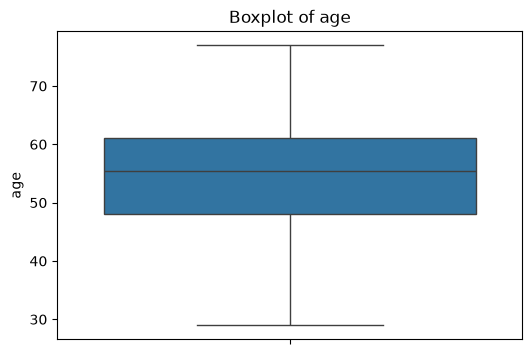

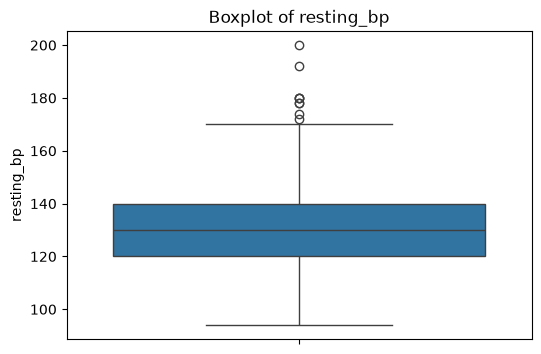

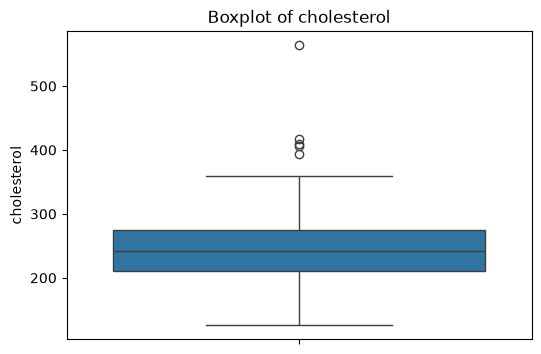

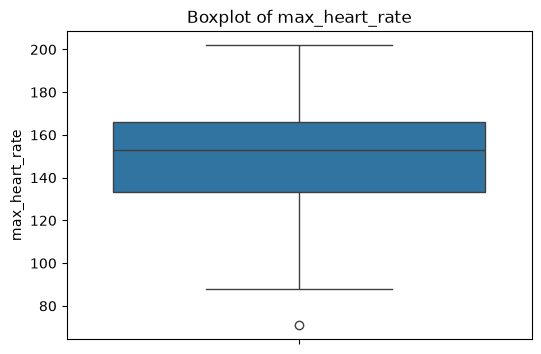

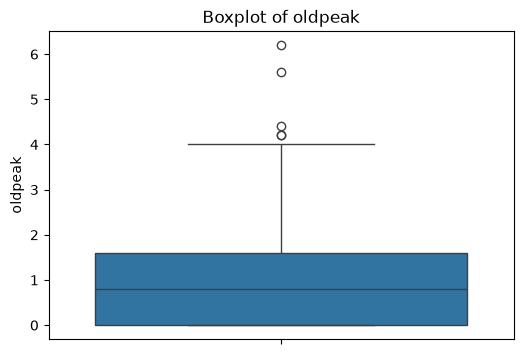

In [32]:
numerical_cols = [
    "age",
    "resting_bp",
    "cholesterol",
    "max_heart_rate",
    "oldpeak"
]

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=hd[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Feature Engineering

In [33]:
hd.columns

Index(['age', 'sex', 'chest_pain', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'slope', 'ca', 'Thal', 'target'],
      dtype='str')

In [34]:
hd.head(10)

,age,sex,chest_pain,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,ca,Thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
5,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
6,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
7,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
8,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1
9,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0


In [35]:
X = hd.drop("target", axis=1)
y = hd["target"]

In [36]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [37]:
print(X.head())
print(y.head())

    age  sex  chest_pain  resting_bp  cholesterol  fasting_blood_sugar  \
0  67.0  1.0         4.0       160.0        286.0                  0.0   
1  67.0  1.0         4.0       120.0        229.0                  0.0   
2  37.0  1.0         3.0       130.0        250.0                  0.0   
3  41.0  0.0         2.0       130.0        204.0                  0.0   
4  56.0  1.0         2.0       120.0        236.0                  0.0   

   resting_ecg  max_heart_rate  exercise_angina  oldpeak  slope   ca  Thal  
0          2.0           108.0              1.0      1.5    2.0  3.0   3.0  
1          2.0           129.0              1.0      2.6    2.0  2.0   7.0  
2          0.0           187.0              0.0      3.5    3.0  0.0   3.0  
3          2.0           172.0              0.0      1.4    1.0  0.0   3.0  
4          0.0           178.0              0.0      0.8    1.0  0.0   3.0  
0    1
1    1
2    0
3    0
4    0
Name: target, dtype: int64


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)

In [39]:
print(y_train.unique())
print(y_test.unique())

[0 1]
[1 0]


In [40]:
print("Feature names:")
print(X_train.columns.tolist())

Feature names:
['age', 'sex', 'chest_pain', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'slope', 'ca', 'Thal']


In [41]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (241, 13)
X_test: (61, 13)


In [42]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
model1_logistic.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [44]:
y_pred_logistic = model1_logistic.predict(X_test)

In [45]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

In [46]:
print(accuracy_logistic)

0.8524590163934426


In [47]:
print(confusion_matrix(y_test, y_pred_logistic))

[[27  5]
 [ 4 25]]


In [48]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       0.83      0.86      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [49]:
model2_svm.fit(X_train, y_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [50]:
y_pred_svm = model2_svm.predict(X_test)

In [51]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

In [52]:
print(accuracy_svm)

0.9016393442622951


In [53]:
print(confusion_matrix(y_test, y_pred_svm))

[[29  3]
 [ 3 26]]


In [54]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        32
           1       0.90      0.90      0.90        29

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [55]:
model3_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [56]:
y_pred_rf = model3_rf.predict(X_test)

In [57]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

In [58]:
print(accuracy_rf)

0.8524590163934426


In [59]:
print(confusion_matrix(y_test, y_pred_rf))

[[28  4]
 [ 5 24]]


In [60]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86        32
           1       0.86      0.83      0.84        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [61]:
model4_xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [62]:
y_pred_xgb = model4_xgb.predict(X_test)

In [63]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

In [64]:
print(accuracy_xgb)

0.8524590163934426


In [65]:
print(confusion_matrix(y_test, y_pred_xgb))

[[27  5]
 [ 4 25]]


In [66]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       0.83      0.86      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [67]:
models = {
    "Logistic Regression": model1_logistic,
    "SVM": model2_svm,
    "Random Forest": model3_rf,
    "XGBoost": model4_xgb
}

results = []                                      

for name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
                         

    results.append({
        'Models': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

print(pd.DataFrame(results))

                Models  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.852459   0.833333  0.862069  0.847458
1                  SVM  0.901639   0.896552  0.896552  0.896552
2        Random Forest  0.852459   0.857143  0.827586  0.842105
3              XGBoost  0.852459   0.833333  0.862069  0.847458


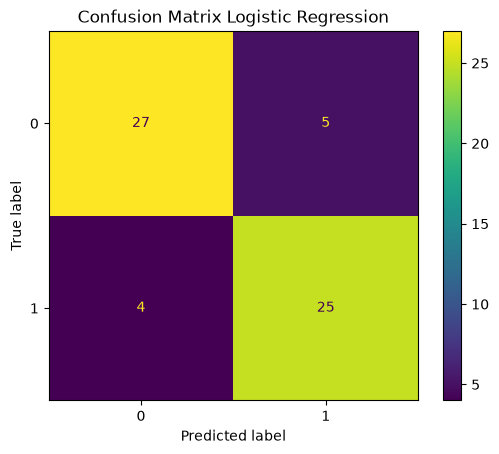

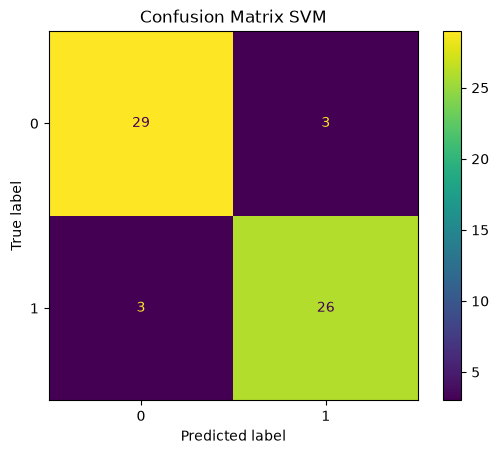

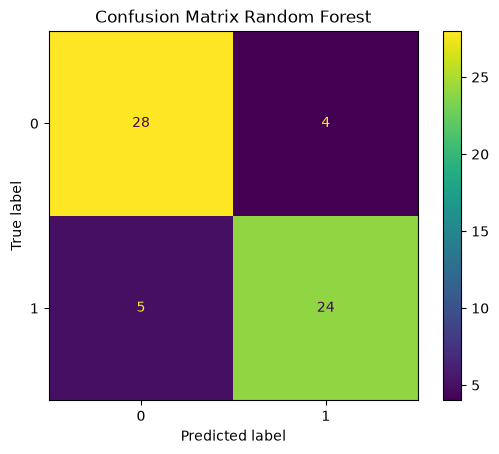

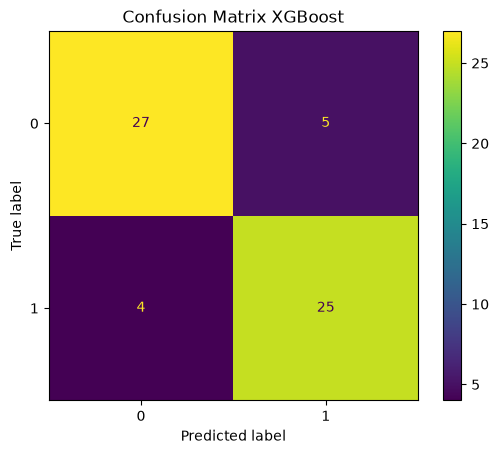

In [68]:
models = {
    "Logistic Regression": model1_logistic,
    "SVM": model2_svm,
    "Random Forest": model3_rf,
    "XGBoost": model4_xgb
}


for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(f"Confusion Matrix {name}")
    plt.show()

In [69]:
joblib.dump(model2_svm, "../model/heart_disease_model.pkl")

['../model/heart_disease_model.pkl']

In [70]:
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']